# Informer 训练结果查看

这个 Notebook 用于查看和可视化 Informer 模型训练后生成的 .npy 格式结果文件。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

In [2]:
# 配置结果文件路径（请根据实际情况修改）
SETTING = 'informer_PJME_ftS_sl168_ll48_pl24_dm512_nh8_el2_dl1_df2048_atprob_fc5_ebtimeF_dtTrue_mxTrue_test_0'  # 实验文件夹名称，例如：'re' 或完整的实验名称
results_dir = os.path.join('./results', SETTING)


# 列出所有 npy 文件
if os.path.exists(results_dir):
    npy_files = [f for f in os.listdir(results_dir) if f.endswith('.npy')]
    print(f"📂 结果目录：{results_dir}")
    print(f"\n找到 {len(npy_files)} 个文件:")
    for i, file in enumerate(npy_files, 1):
        file_path = os.path.join(results_dir, file)
        file_size = os.path.getsize(file_path) / 1024  # KB
        print(f"  {i}. {file:30s} ({file_size:.1f} KB)")
else:
    print(f"❌ 目录不存在：{results_dir}")

📂 结果目录：./results\informer_PJME_ftS_sl168_ll48_pl24_dm512_nh8_el2_dl1_df2048_atprob_fc5_ebtimeF_dtTrue_mxTrue_test_0

找到 3 个文件:
  1. metrics.npy                    (0.1 KB)
  2. pred.npy                       (2721.1 KB)
  3. true.npy                       (2721.1 KB)


## 1. 查看评估指标

📊 评估指标

文件：./results\informer_PJME_ftS_sl168_ll48_pl24_dm512_nh8_el2_dl1_df2048_atprob_fc5_ebtimeF_dtTrue_mxTrue_test_0\metrics.npy

详细指标:
------------------------------------------------------------
MAE     : 0.202076
MSE     : 0.083910
RMSE    : 0.289671
MAPE    : 1.561541
MSPE    : 2740.057373
------------------------------------------------------------


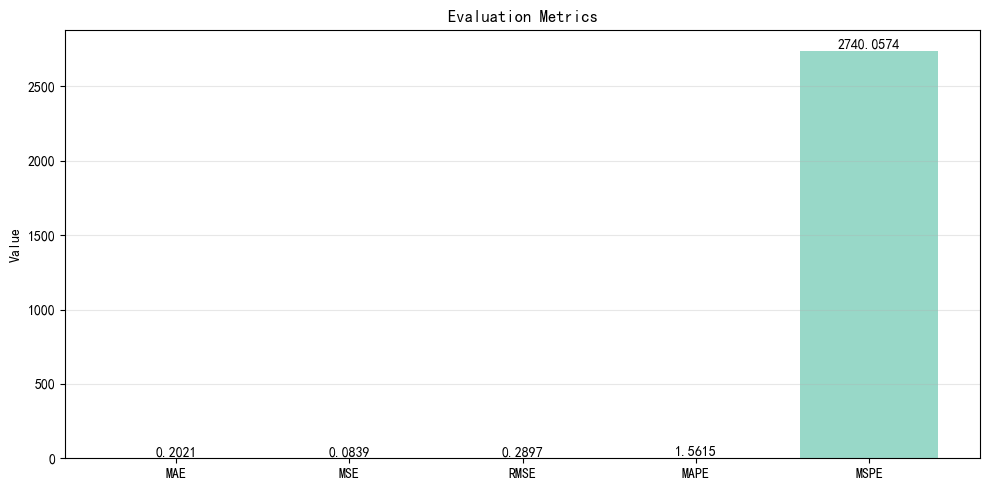

In [3]:
# 加载评估指标
metrics_file = os.path.join(results_dir, 'metrics.npy')

if os.path.exists(metrics_file):
    metrics = np.load(metrics_file)
    metric_names = ['MAE', 'MSE', 'RMSE', 'MAPE', 'MSPE']
    
    print("="*60)
    print("📊 评估指标")
    print("="*60)
    print(f"\n文件：{metrics_file}")
    print(f"\n详细指标:")
    print("-" * 60)
    for name, value in zip(metric_names, metrics):
        print(f"{name:8s}: {value:.6f}")
    print("-" * 60)
    
    # 可视化指标
    plt.figure(figsize=(10, 5))
    plt.bar(metric_names, metrics, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'])
    plt.ylabel('Value')
    plt.title('Evaluation Metrics')
    plt.grid(axis='y', alpha=0.3)
    
    # 在柱子上标注数值
    for i, v in enumerate(metrics):
        plt.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ 未找到 metrics.npy 文件")

## 2. 查看预测结果统计信息

In [4]:
# 加载预测值和真实值
pred_file = os.path.join(results_dir, 'pred.npy')
true_file = os.path.join(results_dir, 'true.npy')

if os.path.exists(pred_file):
    preds = np.load(pred_file)
    print("="*60)
    print("📈 预测结果分析")
    print("="*60)
    print(f"\n文件：{pred_file}")
    print(f"数据形状：{preds.shape}")
    
    if len(preds.shape) == 3:
        n_samples, n_steps, n_vars = preds.shape
        print(f"  - 样本数：{n_samples}")
        print(f"  - 预测步长：{n_steps}")
        print(f"  - 变量数：{n_vars}")
    
    print(f"\n统计信息:")
    print(f"  最小值：{preds.min():.6f}")
    print(f"  最大值：{preds.max():.6f}")
    print(f"  平均值：{preds.mean():.6f}")
    print(f"  标准差：{preds.std():.6f}")
    
    # 如果有真实值
    if os.path.exists(true_file):
        trues = np.load(true_file)
        print(f"\n真实值统计:")
        print(f"  最小值：{trues.min():.6f}")
        print(f"  最大值：{trues.max():.6f}")
        print(f"  平均值：{trues.mean():.6f}")
        print(f"  标准差：{trues.std():.6f}")
        
        # 计算误差
        error = np.abs(preds - trues)
        print(f"\n绝对误差统计:")
        print(f"  平均绝对误差：{error.mean():.6f}")
        print(f"  最大绝对误差：{error.max():.6f}")
else:
    print("❌ 未找到 pred.npy 文件")

📈 预测结果分析

文件：./results\informer_PJME_ftS_sl168_ll48_pl24_dm512_nh8_el2_dl1_df2048_atprob_fc5_ebtimeF_dtTrue_mxTrue_test_0\pred.npy
数据形状：(29024, 24, 1)
  - 样本数：29024
  - 预测步长：24
  - 变量数：1

统计信息:
  最小值：-2.169870
  最大值：3.797158
  平均值：-0.178731
  标准差：0.955994

真实值统计:
  最小值：-2.025378
  最大值：3.724479
  平均值：-0.205711
  标准差：0.997667

绝对误差统计:
  平均绝对误差：0.202076
  最大绝对误差：2.175097


## 3. 可视化预测曲线

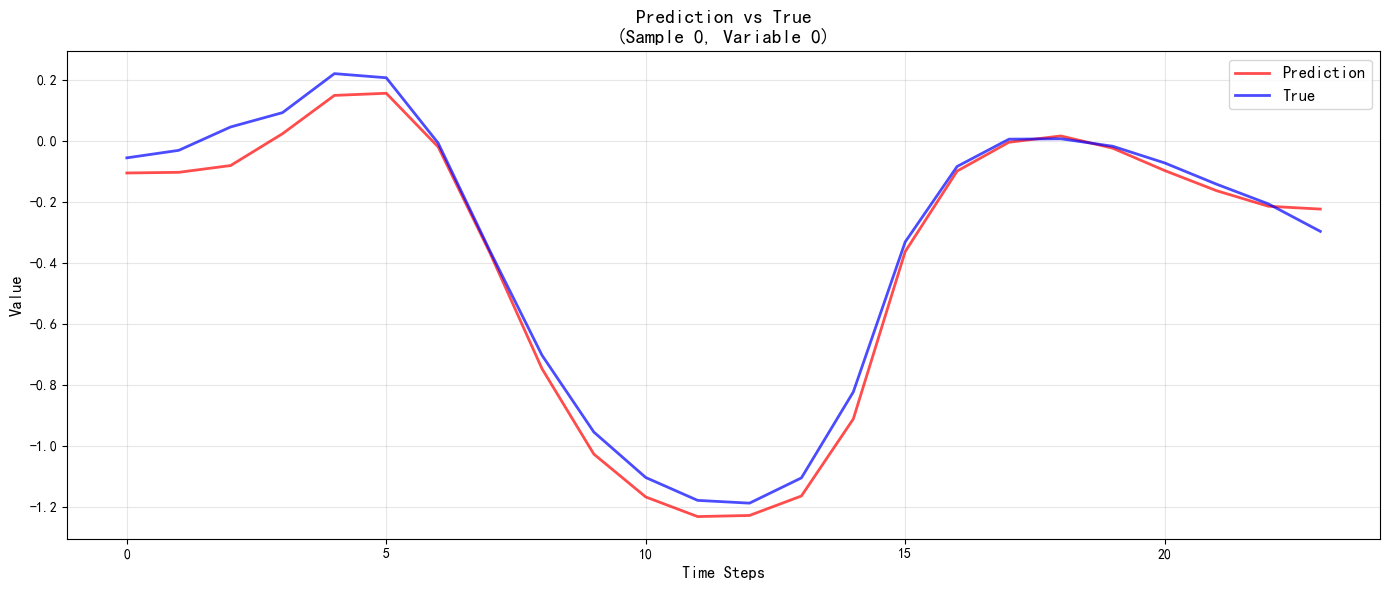

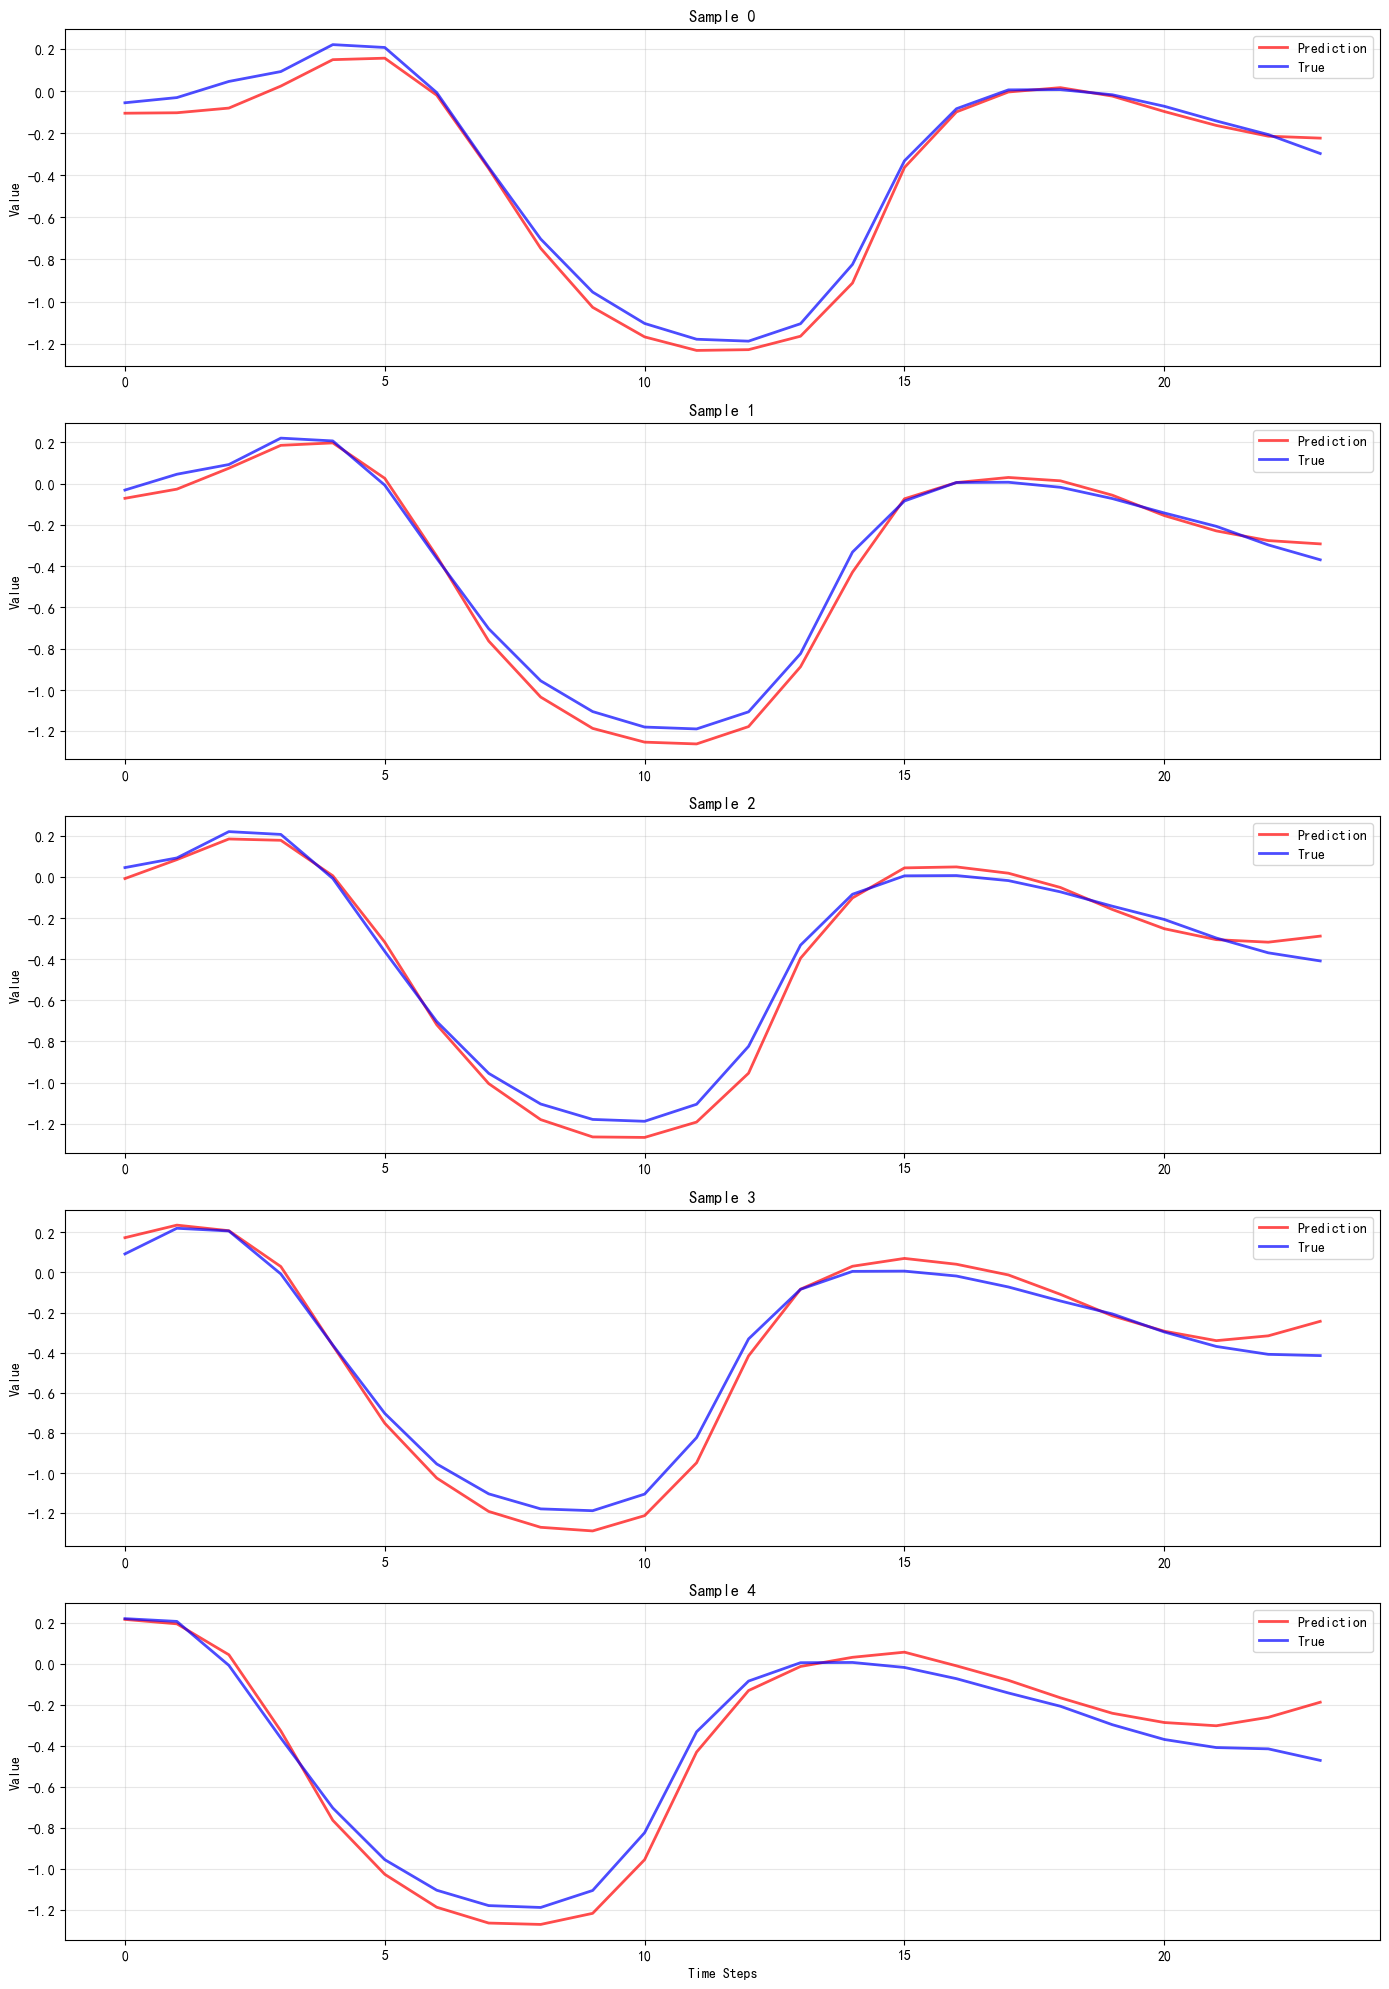

In [5]:
# 可视化前几个样本的预测
if os.path.exists(pred_file) and os.path.exists(true_file):
    preds = np.load(pred_file)
    trues = np.load(true_file)
    
    # 确保是 3D 数据： (n_samples, time_steps, n_vars)
    if len(preds.shape) == 2:
        preds = preds.reshape(preds.shape[0], preds.shape[1], 1)
        trues = trues.reshape(trues.shape[0], trues.shape[1], 1)
    
    # 选择要可视化的样本和变量
    sample_idx = 0  # 第一个样本
    variable_idx = 0  # 第一个变量
    
    plt.figure(figsize=(14, 6))
    
    time_steps = preds.shape[1]
    time_axis = np.arange(time_steps)
    
    # 绘制预测值
    pred_line = preds[sample_idx, :, variable_idx]
    plt.plot(time_axis, pred_line, 'r-', label='Prediction', linewidth=2, alpha=0.7)
    
    # 绘制真实值
    true_line = trues[sample_idx, :, variable_idx]
    plt.plot(time_axis, true_line, 'b-', label='True', linewidth=2, alpha=0.7)
    
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Value', fontsize=12)
    plt.title(f'Prediction vs True\n(Sample {sample_idx}, Variable {variable_idx})', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 绘制多个样本
    n_samples_to_show = min(5, preds.shape[0])
    fig, axes = plt.subplots(n_samples_to_show, 1, figsize=(14, 4*n_samples_to_show))
    
    if n_samples_to_show == 1:
        axes = [axes]
    
    for idx, ax in enumerate(axes):
        pred_line = preds[idx, :, variable_idx]
        true_line = trues[idx, :, variable_idx]
        
        ax.plot(time_axis, pred_line, 'r-', label='Prediction', linewidth=2, alpha=0.7)
        ax.plot(time_axis, true_line, 'b-', label='True', linewidth=2, alpha=0.7)
        ax.set_ylabel('Value')
        ax.set_title(f'Sample {idx}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time Steps')
    plt.tight_layout()
    plt.show()

## 4. 误差分布分析

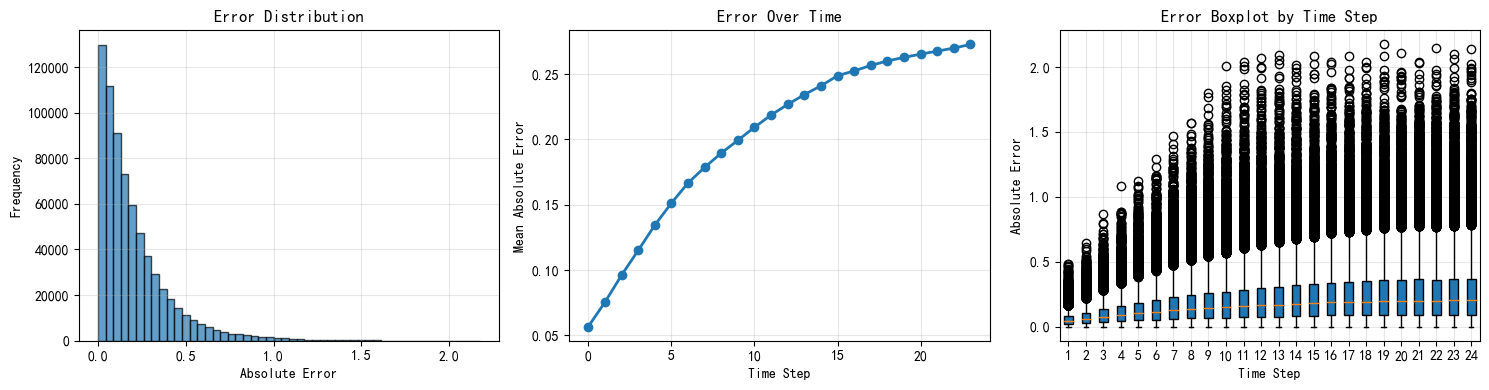

In [6]:
# 分析误差分布
if os.path.exists(pred_file) and os.path.exists(true_file):
    preds = np.load(pred_file)
    trues = np.load(true_file)
    
    # 计算绝对误差
    abs_error = np.abs(preds - trues)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # 误差直方图
    axes[0].hist(abs_error.flatten(), bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Absolute Error')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Error Distribution')
    axes[0].grid(True, alpha=0.3)
    
    # 误差随时间变化
    time_axis = np.arange(abs_error.shape[1])
    mean_error = abs_error.mean(axis=(0, 2)) if len(abs_error.shape) == 3 else abs_error.mean(axis=0)
    axes[1].plot(time_axis, mean_error, 'o-', linewidth=2)
    axes[1].set_xlabel('Time Step')
    axes[1].set_ylabel('Mean Absolute Error')
    axes[1].set_title('Error Over Time')
    axes[1].grid(True, alpha=0.3)
    
    # 箱线图显示误差分布
    if len(abs_error.shape) == 3:
        error_per_step = [abs_error[:, t, :].flatten() for t in range(abs_error.shape[1])]
    else:
        error_per_step = [abs_error[:, t].flatten() for t in range(abs_error.shape[1])]
    
    axes[2].boxplot(error_per_step, patch_artist=True)
    axes[2].set_xlabel('Time Step')
    axes[2].set_ylabel('Absolute Error')
    axes[2].set_title('Error Boxplot by Time Step')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 6. 完整序列可视化（历史输入 + 预测对比）⭐

### 6.1 定义可视化函数

In [7]:
def plot_prediction_with_history(setting, sample_idx=0, variable_idx=0,
                                  seq_len=168, label_len=48, pred_len=24,
                                  data_root='./data', data_path='PJME_hourly.csv',
                                  features='S', target='PJME_MW'):
    """
    可视化单个样本的完整预测过程：历史输入 + 预测对比
    
    参数:
    - setting: 实验名称字符串 (如 'informer_PJME_ftS_sl96_ll48_pl24_...')
    - sample_idx: 第几个测试样本 (0 ~ 测试集长度 -1)
    - variable_idx: 哪个变量 (对于 S 模式固定为 0)
    - seq_len: 编码器输入序列长度（必须与训练时一致）
    - label_len: 解码器起始标记长度（必须与训练时一致）
    - pred_len: 预测序列长度（必须与训练时一致）
    - data_root: 数据集根目录
    - data_path: 数据文件名
    - features: 预测模式 (S/M/MS)
    - target: 目标特征名
    """
    
    # 1. 加载预测结果
    results_dir = f'./results/{setting}/'
    pred_file = os.path.join(results_dir, 'pred.npy')
    true_file = os.path.join(results_dir, 'true.npy')
    
    if not os.path.exists(pred_file) or not os.path.exists(true_file):
        print(f"❌ 结果文件不存在：{results_dir}")
        return
    
    preds = np.load(pred_file)
    trues = np.load(true_file)
    
    # 验证 sample_idx 范围
    n_samples = preds.shape[0]
    if sample_idx < 0 or sample_idx >= n_samples:
        print(f"❌ sample_idx 超出范围！有效范围：0 ~ {n_samples-1}")
        return
    
    # 2. 重新加载测试数据集
    from data.data_loader import Dataset_Custom
    test_dataset = Dataset_Custom(
        root_path=data_root,
        data_path=data_path,
        flag='test',
        size=[seq_len, label_len, pred_len],
        features=features,
        target=target,
        timeenc=1,
        freq='h'
    )
    
    # 3. 获取指定样本的数据
    seq_x, seq_y, seq_x_mark, seq_y_mark = test_dataset[sample_idx]
    
    # seq_x: 历史输入 [seq_len, n_vars]
    # seq_y: Decoder 输入 [label_len+pred_len, n_vars]
    
    # 4. 提取数据
    if isinstance(seq_x, np.ndarray):
        history_data = seq_x[:, variable_idx]
    else:
        history_data = seq_x[:, variable_idx].numpy()
    
    pred_data = preds[sample_idx, :, variable_idx]
    true_data = trues[sample_idx, :, variable_idx]
    
    # 5. 创建时间轴（0 ~ seq_len+pred_len-1）
    total_len = seq_len + pred_len
    time_axis = np.arange(total_len)

    # 6. 构造要绘制的序列
    # 预测曲线：历史输入 + 预测结果 拼成一条完整的线
    full_pred = np.concatenate([history_data, pred_data])  # 长度 seq_len + pred_len

    # 真实曲线：只在预测区间上有（与 pred 对齐）
    true_time = np.arange(seq_len, seq_len + pred_len)

    # 7. 绘图
    fig, ax = plt.subplots(figsize=(4,3))

    # 绘制完整预测曲线（灰+橙，一条线）
    ax.plot(time_axis, full_pred, color='#f28e2b', linewidth=2.5,
            label='History + Prediction', marker='o', markersize=3, alpha=0.8)

    # 绘制真实值（只在预测区间）
    ax.plot(true_time, true_data, color='#4e79a7', linewidth=2.5,
            label='True (Prediction Range)', marker='s', markersize=4, alpha=0.8)

    # 设置标签和标题
    ax.set_xlabel('Time Steps', fontsize=13, fontweight='bold')
    ax.set_ylabel('Normalized Value', fontsize=13, fontweight='bold')
    ax.set_title(
        'Informer Prediction Visualization (Continuous Sequence)\n'
        f'Sample {sample_idx} | MSE: {((pred_data-true_data)**2).mean():.6f} | '
        f'MAE: {np.abs(pred_data-true_data).mean():.6f}',
        fontsize=14, fontweight='bold'
    )

    ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='-')
    ax.set_xlim(0, total_len - 1)

    # 添加网格
    ax.xaxis.grid(True, which='major', linestyle='--', alpha=0.5)
    ax.yaxis.grid(True, which='major', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()
    
    # 打印详细信息
    print("\n" + "="*80)
    print(f"📊 样本 {sample_idx} 详细信息")
    print("="*80)
    print(f"历史输入长度 (seq_len): {seq_len}")
    print(f"预测长度 (pred_len): {pred_len}")
    print(f"变量索引：{variable_idx}")
    print(f"\n预测统计:")
    print(f"  最小值：{pred_data.min():.6f}")
    print(f"  最大值：{pred_data.max():.6f}")
    print(f"  平均值：{pred_data.mean():.6f}")
    print(f"\n真实值统计:")
    print(f"  最小值：{true_data.min():.6f}")
    print(f"  最大值：{true_data.max():.6f}")
    print(f"  平均值：{true_data.mean():.6f}")
    print(f"\n误差统计:")
    mse = ((pred_data - true_data)**2).mean()
    mae = np.abs(pred_data - true_data).mean()
    rmse = np.sqrt(mse)
    print(f"  MSE:  {mse:.6f}")
    print(f"  RMSE: {rmse:.6f}")
    print(f"  MAE:  {mae:.6f}")
    print("="*80)

### 6.2 使用示例（交互式可视化）

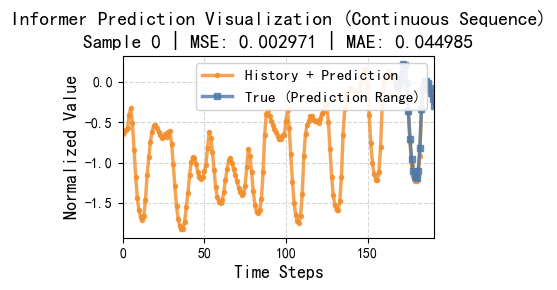


📊 样本 0 详细信息
历史输入长度 (seq_len): 168
预测长度 (pred_len): 24
变量索引：0

预测统计:
  最小值：-1.232193
  最大值：0.155745
  平均值：-0.375315

真实值统计:
  最小值：-1.188159
  最大值：0.220135
  平均值：-0.337202

误差统计:
  MSE:  0.002971
  RMSE: 0.054510
  MAE:  0.044985


In [8]:
# ========== 配置参数 ==========
# 请根据你的实验设置修改这些参数

SETTING = 'informer_PJME_ftS_sl168_ll48_pl24_dm512_nh8_el2_dl1_df2048_atprob_fc5_ebtimeF_dtTrue_mxTrue_test_0'  # 实验文件夹名称，例如：'re' 或完整的实验名称

# 模型参数（必须与训练时一致！）
SEQ_LEN = 168     # 编码器输入长度
LABEL_LEN = 48    # 解码器起始标记长度
PRED_LEN = 24     # 预测长度

# 数据集配置
DATA_ROOT = './data'
DATA_PATH = 'PJME_hourly.csv'
FEATURES = 'S'        # S:单变量，M:多变量，MS:多变量预测单变量
TARGET = 'PJME_MW'    # 目标特征名称

# 选择要可视化的样本
SAMPLE_IDX = 0        # 可以修改为 0 ~ 29023 之间的任意整数
VARIABLE_IDX = 0      # 对于 S 模式，固定为 0

# ========== 调用可视化函数 ==========
plot_prediction_with_history(
    setting=SETTING,
    sample_idx=SAMPLE_IDX,
    variable_idx=VARIABLE_IDX,
    seq_len=SEQ_LEN,
    label_len=LABEL_LEN,
    pred_len=PRED_LEN,
    data_root=DATA_ROOT,
    data_path=DATA_PATH,
    features=FEATURES,
    target=TARGET
)

### 6.3 批量查看多个样本（可选）


查看样本 0/5



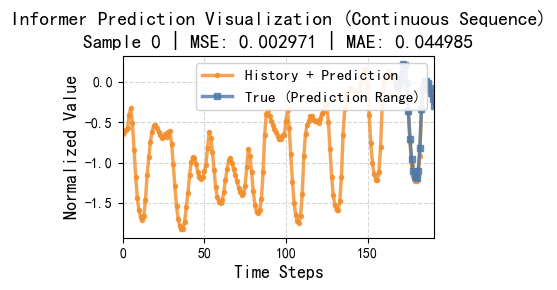


📊 样本 0 详细信息
历史输入长度 (seq_len): 168
预测长度 (pred_len): 24
变量索引：0

预测统计:
  最小值：-1.232193
  最大值：0.155745
  平均值：-0.375315

真实值统计:
  最小值：-1.188159
  最大值：0.220135
  平均值：-0.337202

误差统计:
  MSE:  0.002971
  RMSE: 0.054510
  MAE:  0.044985

查看样本 1/5



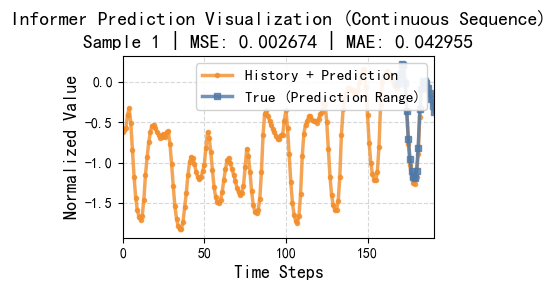


📊 样本 1 详细信息
历史输入长度 (seq_len): 168
预测长度 (pred_len): 24
变量索引：0

预测统计:
  最小值：-1.260791
  最大值：0.196947
  平均值：-0.374563

真实值统计:
  最小值：-1.188159
  最大值：0.220135
  平均值：-0.350248

误差统计:
  MSE:  0.002674
  RMSE: 0.051707
  MAE:  0.042955

查看样本 2/5



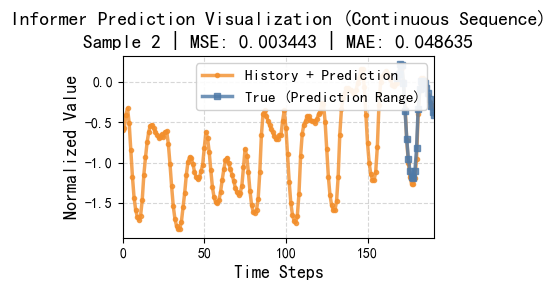


📊 样本 2 详细信息
历史输入长度 (seq_len): 168
预测长度 (pred_len): 24
变量索引：0

预测统计:
  最小值：-1.266615
  最大值：0.184393
  平均值：-0.383909

真实值统计:
  最小值：-1.188159
  最大值：0.220135
  平均值：-0.365961

误差统计:
  MSE:  0.003443
  RMSE: 0.058675
  MAE:  0.048635

查看样本 3/5



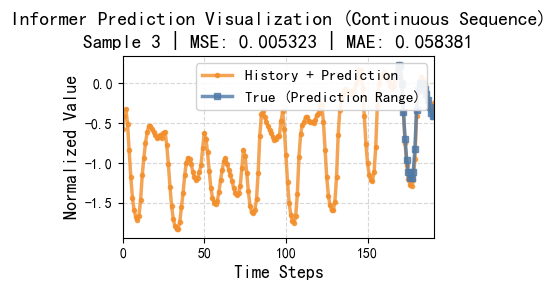


📊 样本 3 详细信息
历史输入长度 (seq_len): 168
预测长度 (pred_len): 24
变量索引：0

预测统计:
  最小值：-1.288990
  最大值：0.235781
  平均值：-0.387471

真实值统计:
  最小值：-1.188159
  最大值：0.220135
  平均值：-0.385132

误差统计:
  MSE:  0.005323
  RMSE: 0.072960
  MAE:  0.058381

查看样本 4/5



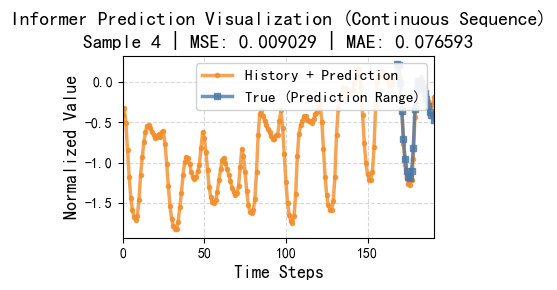


📊 样本 4 详细信息
历史输入长度 (seq_len): 168
预测长度 (pred_len): 24
变量索引：0

预测统计:
  最小值：-1.270897
  最大值：0.216278
  平均值：-0.399044

真实值统计:
  最小值：-1.188159
  最大值：0.220135
  平均值：-0.408606

误差统计:
  MSE:  0.009029
  RMSE: 0.095020
  MAE:  0.076593


In [9]:
# 如果你想快速浏览多个样本，可以修改 SAMPLE_IDX 并重复运行上面的单元格
# 或者使用下面的代码批量查看

# 批量查看前 5 个样本
for idx in range(5):
    print(f"\n{'='*80}")
    print(f"查看样本 {idx}/5")
    print(f"{'='*80}\n")
    
    plot_prediction_with_history(
        setting=SETTING,
        sample_idx=idx,
        variable_idx=VARIABLE_IDX,
        seq_len=SEQ_LEN,
        label_len=LABEL_LEN,
        pred_len=PRED_LEN,
        data_root=DATA_ROOT,
        data_path=DATA_PATH,
        features=FEATURES,
        target=TARGET
    )

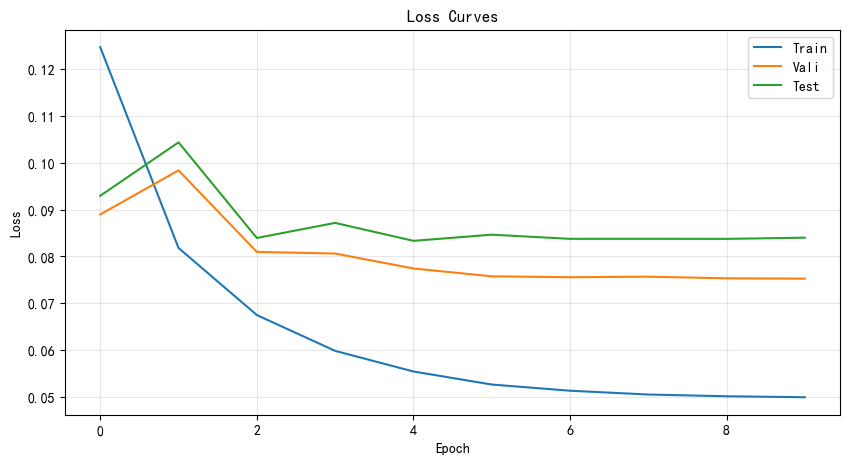

In [10]:
import numpy as np
import os

setting = 'informer_PJME_ftS_sl168_ll48_pl24_dm512_nh8_el2_dl1_df2048_atprob_fc5_ebtimeF_dtTrue_mxTrue_test_0'
ckpt_dir = os.path.join('./checkpoints', setting)
hist_file = os.path.join(ckpt_dir, 'history.npy')

if os.path.exists(hist_file):
    history = np.load(hist_file, allow_pickle=True).item()
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['vali_loss'], label='Vali')
    plt.plot(history['test_loss'], label='Test')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curves')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('未找到 loss_history.npy')